In [87]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [88]:
df = pd.read_csv("/content/MBA.csv")
df

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN
...,...,...,...,...,...,...,...,...,...,...
6189,6190,Male,False,3.49,Business,White,640.0,5.0,Other,NaN
6190,6191,Male,False,3.18,STEM,Black,670.0,4.0,Consulting,NaN
6191,6192,Female,True,3.22,Business,NaN,680.0,5.0,Health Care,Admit
6192,6193,Male,True,3.36,Business,NaN,590.0,5.0,Other,NaN


In [89]:
df.shape

(6194, 10)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [91]:
df.describe()

,application_id,gpa,gmat,work_exp
count,6194.000000,6194.000000,6194.000000,6194.000000
mean,3097.500000,3.250714,651.092993,5.016952
std,1788.198115,0.151541,49.294883,1.032432
min,1.000000,2.650000,570.000000,1.000000
25%,1549.250000,3.150000,610.000000,4.000000
50%,3097.500000,3.250000,650.000000,5.000000
75%,4645.750000,3.350000,680.000000,6.000000
max,6194.000000,3.770000,780.000000,9.000000


In [92]:
df.isnull().sum()

,0
application_id,0
gender,0
international,0
gpa,0
major,0
race,1842
gmat,0
work_exp,0
work_industry,0
admission,5194


In [93]:
df_clean = df.dropna()


In [94]:
df_final = pd.get_dummies(df_clean, columns=['gender','international','work_industry','major'], drop_first=True)


In [95]:
df.drop(columns=["race"], inplace=True)

In [96]:
# Missing indicator
df["admission"] = (
    df["admission"]
    .isnull()
    .astype(int)
)

# Fill missing values
df["admission"] = (
    df["admission"]
    .fillna(-1)
)

In [97]:
df.isnull().sum()

,0
application_id,0
gender,0
international,0
gpa,0
major,0
gmat,0
work_exp,0
work_industry,0
admission,0


In [98]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [99]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'application_id': 0, 'gpa': 44, 'gmat': 0, 'work_exp': 0, 'admission': 1000}


In [100]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

           Column  Outlier_Count
4       admission           1000
1             gpa             44
0  application_id              0
2            gmat              0
3        work_exp              0


In [101]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

           Column  Outlier_Count  Percentage
4       admission           1000   16.144656
1             gpa             44    0.710365
0  application_id              0    0.000000
2            gmat              0    0.000000
3        work_exp              0    0.000000


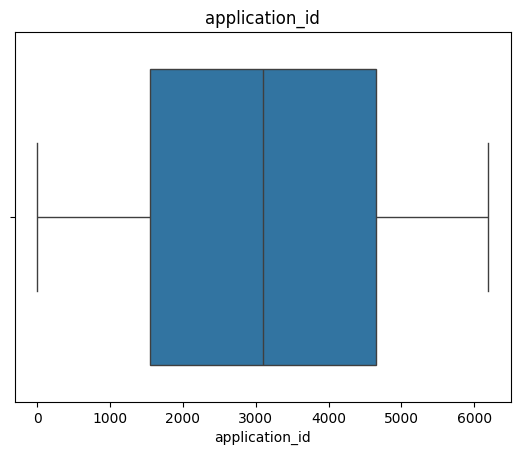

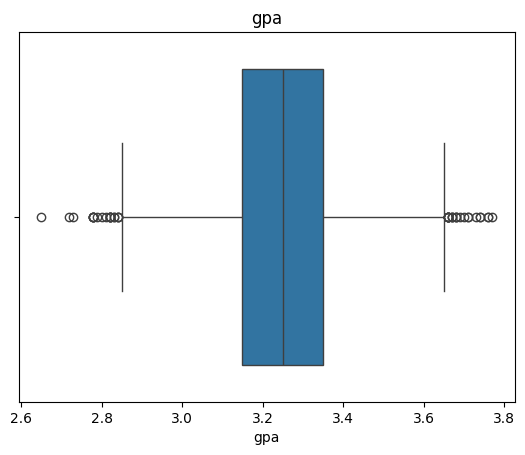

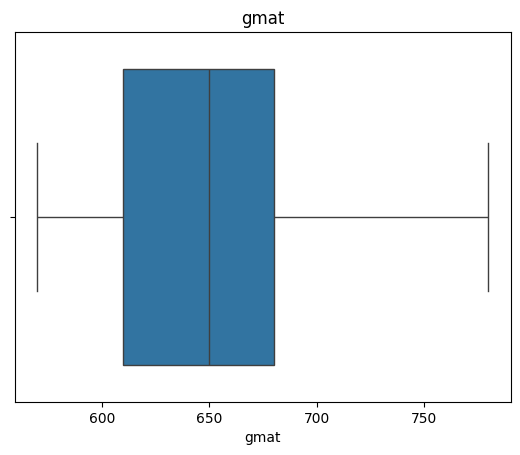

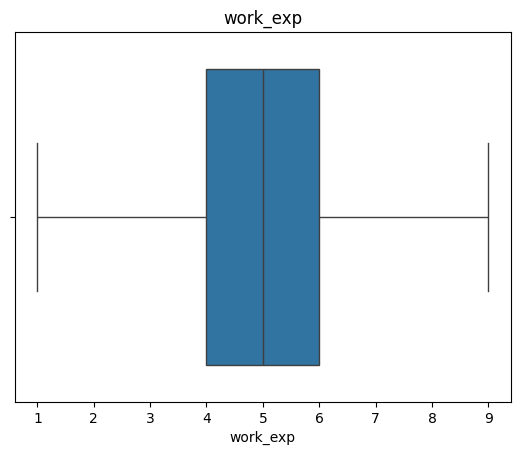

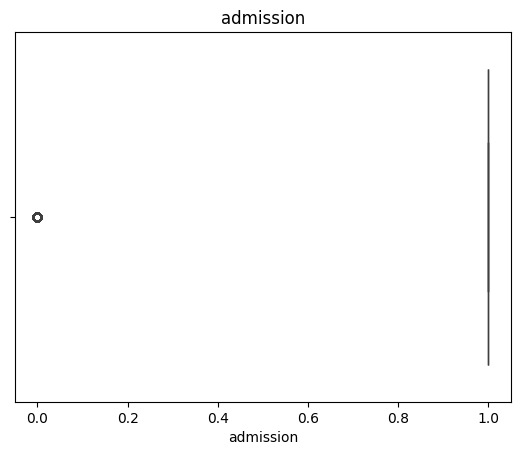

In [102]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [103]:
cols_to_cap = [
    'gpa',
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

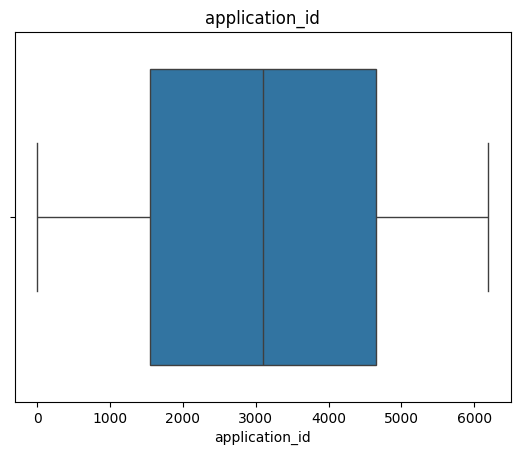

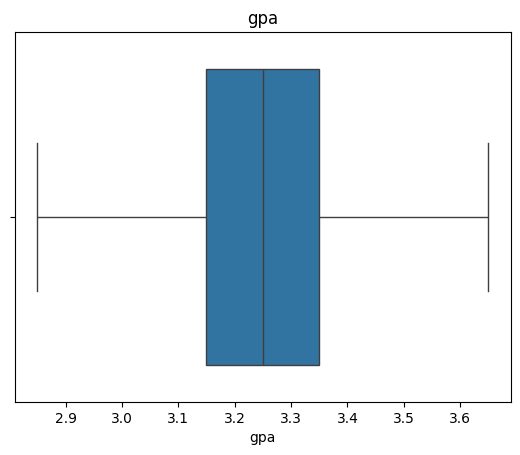

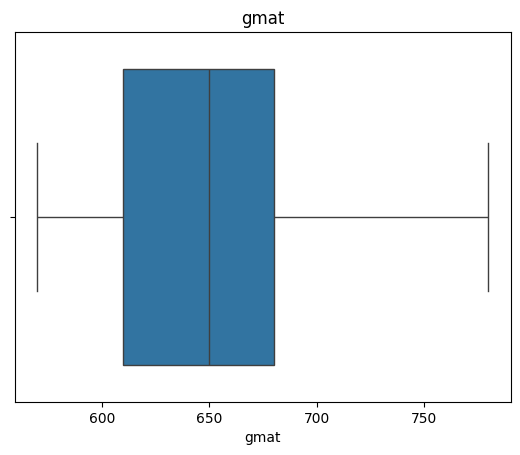

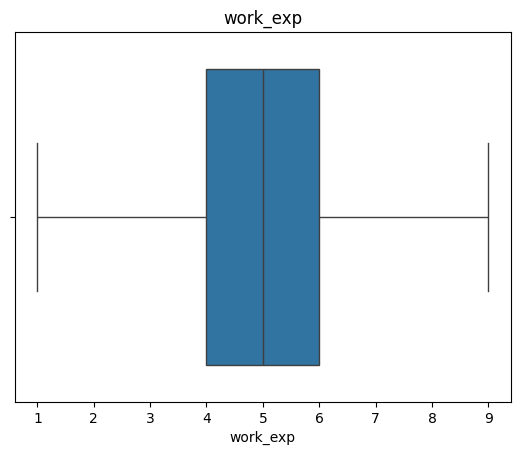

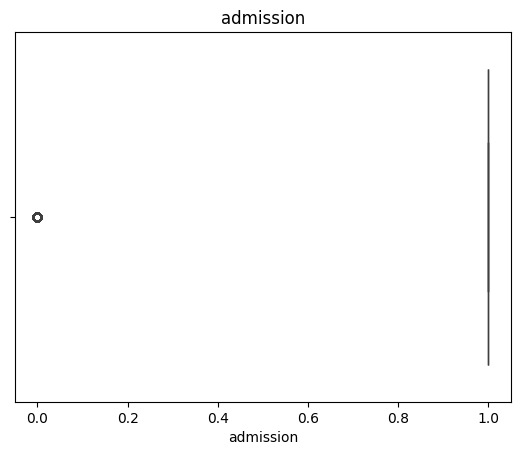

In [104]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [105]:
df["admission"].value_counts()

,count
admission,
1,5194
0,1000


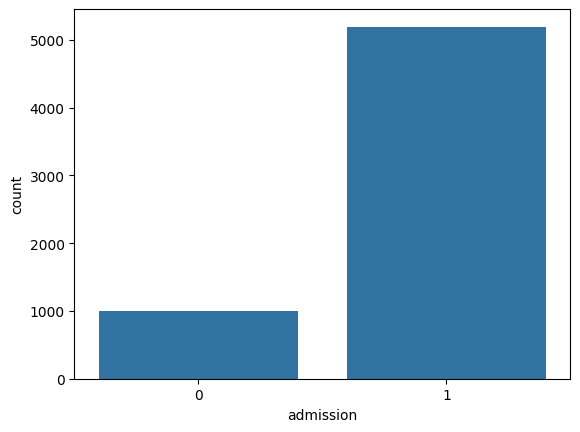

In [106]:
sns.countplot(x=df["admission"])
plt.show()

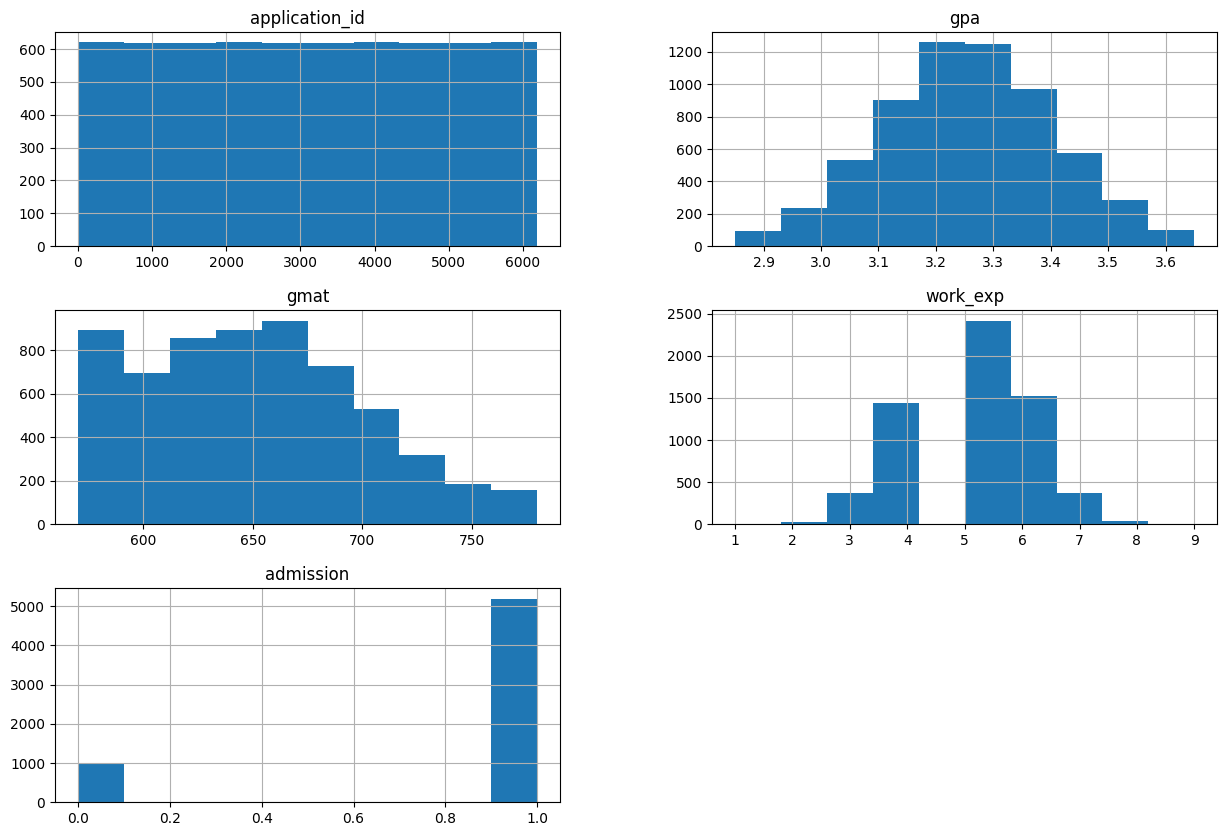

In [107]:
df.hist(figsize=(15,10))
plt.show()

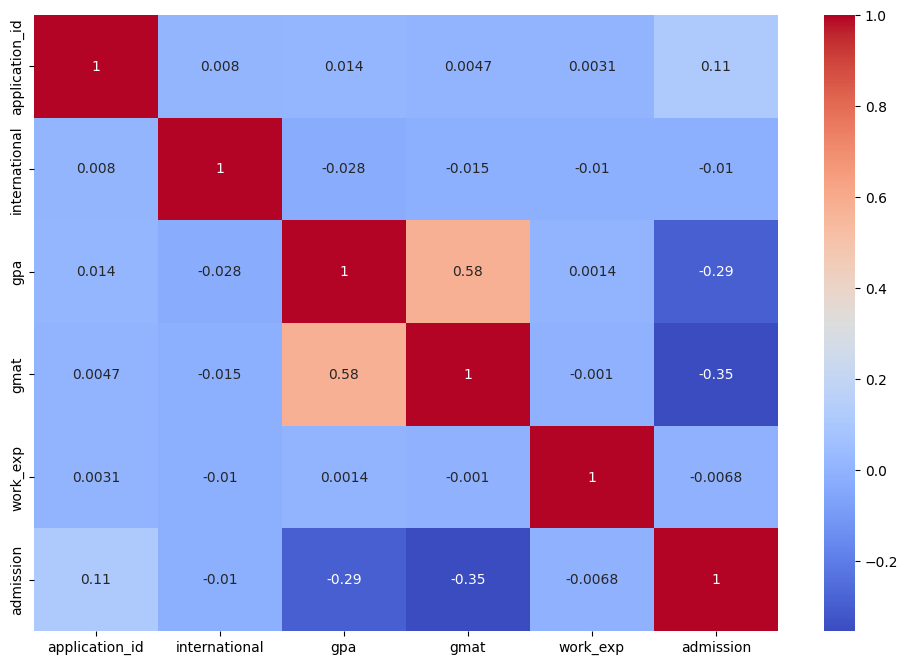

In [108]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


In [109]:
df.head()

,application_id,gender,international,gpa,major,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,620.0,3.0,Financial Services,0
1,2,Male,False,3.28,Humanities,680.0,5.0,Investment Management,1
2,3,Female,True,3.30,Business,710.0,5.0,Technology,0
3,4,Male,False,3.47,STEM,690.0,6.0,Technology,1
4,5,Male,False,3.35,STEM,590.0,5.0,Consulting,1


In [110]:
nominal_cols = ['gender', 'international', 'major', 'work_industry']
# Note: 'gpa', 'gmat', aur 'work_exp' direct numbers hain, inhein encode karne ki zaroorat nahi hoti.


In [111]:
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [112]:
df.dtypes

,0
application_id,int64
gpa,float64
gmat,float64
work_exp,float64
admission,int64
gender_Male,bool
international_True,bool
major_Humanities,bool
major_STEM,bool
work_industry_Consulting,bool


In [113]:
X = df.drop("admission", axis=1)

y = df["admission"]

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [115]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [116]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [117]:
accuracy_score(y_test, y_pred_dt)

0.8587570621468926

In [118]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.69      0.23      0.34       200
           1       0.87      0.98      0.92      1039

    accuracy                           0.86      1239
   macro avg       0.78      0.60      0.63      1239
weighted avg       0.84      0.86      0.83      1239



In [119]:
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

[[  46  154]
 [  21 1018]]


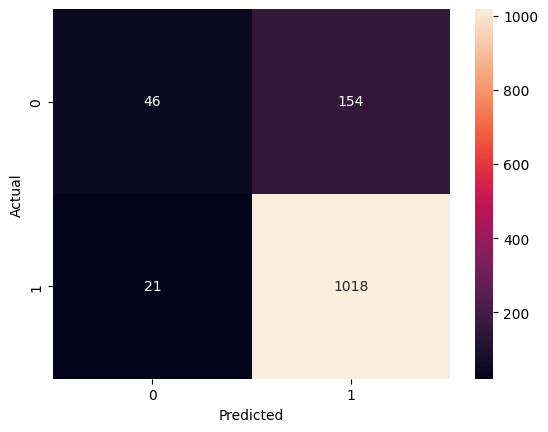

In [120]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [121]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
2,gmat,0.392577
4,gender_Male,0.227194
0,application_id,0.166297
1,gpa,0.166167
5,international_True,0.027407
10,work_industry_Financial Services,0.011721
20,work_industry_Technology,0.005295
3,work_exp,0.003342
7,major_STEM,0.000000
8,work_industry_Consulting,0.000000


In [122]:
train_acc = dt.score(X_train, y_train)

test_acc = dt.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8657921291624622
Testing Accuracy: 0.8587570621468926


In [123]:
dt.get_depth()

5

In [124]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    dt,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.24535916 0.65778854 0.73607748 0.83615819 0.83844911]
0.6627664970317143


In [125]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_pred_dt)

np.float64(0.6048941289701636)

In [126]:
from sklearn.metrics import roc_curve, auc

y_prob = dt.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [127]:
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.8884480269489895


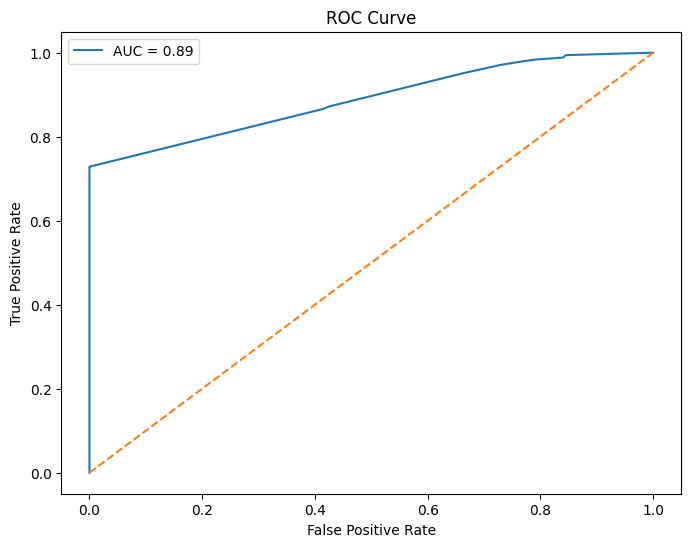

In [128]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()